In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_gridsearch_refined_fine"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")


Found 180 result files

Total loaded: 180 results


In [2]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
        
        # Extract cluster parameters
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
        else:
            cluster_f = None
            n_subtypes = 0
        
        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan
        
        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []
        
        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("final_lse").reset_index(drop=True)
print("\n=== Summary Statistics (sorted by LSE) ===")
print(summary_df[["candidate", "final_lse", "n_subtypes", "scalar_K", "mean_s"]].head(10))

# Find best model (lowest LSE)
best_row = summary_df.iloc[0]
best_key = best_row["key"]
best_data = results[best_key]

print(f"Key: {best_key}")
print(f"Final LSE: {best_row['final_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")



=== Summary Statistics (sorted by LSE) ===
  candidate   final_lse  n_subtypes              scalar_K    mean_s
0       103  611.743849           2   0.04325942507541538  0.949596
1        23  694.417638           2  0.030131337810075296  0.907538
2         3  699.863852           2  0.037723024643891365  0.924450
3         7  703.962317           2   0.03673380232781289  0.929452
4        11  707.294226           2  0.018134616890483776  0.850091
5         0  720.967400           2   0.13590192707502136  0.497770
6         5  722.113326           2   0.13336706490728228  0.498595
7         9  722.302897           2   0.13256054764192648  0.498473
8        50  723.562684           2   0.14310095798749373  0.498293
9        12  726.570777           2    0.1451979842385529  0.494489
Key: PPMI_subtyping_grid_103_lambda_f0p300_lambda_cog0p100_lambda_scalar0p500_lambda_jsd0p100_lambda_beta1p000
Final LSE: 611.743849

Parameters:
  lambda_f: 0.3
  lambda_cog: 0.1
  lambda_scalar: 0.5
  lambd

In [3]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [4]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

print(f"Valid patients: {len(np.unique(ids_valid))}")
print(f"Subtype 1: {np.sum(assignment_valid == 0)} patients")
print(f"Subtype 2: {np.sum(assignment_valid == 1)} patients")


Valid patients: 146
Subtype 1: 286 patients
Subtype 2: 218 patients



All subgroup types found: ['GBA' 'LRRK2' 'PRKN' 'Sporadic PD']

=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===
Clinical Subgroup   GBA  LRRK2  PRKN  Sporadic PD
Discovered Subtype                               
0                     2      1     2           78
1                     4      0     3           56

Chi-square test:
  χ² = 2.7913
  p-value = 0.4249
  df = 3


<Figure size 1200x600 with 0 Axes>

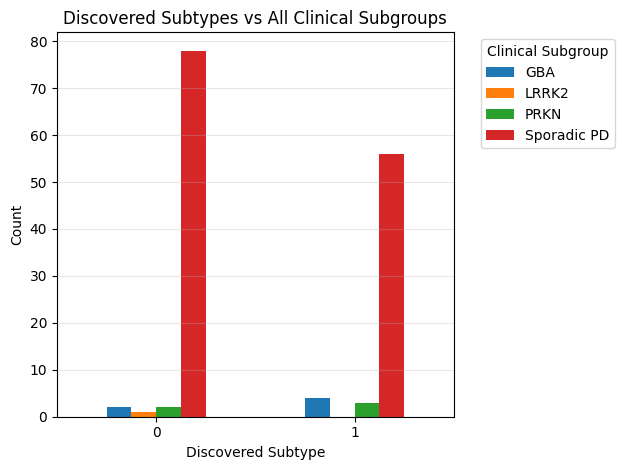

Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 5           78
1                                 7           56

Chi-square test (binary):
  χ² = 0.6468
  p-value = 0.4213
  df = 1


<Figure size 1000x600 with 0 Axes>

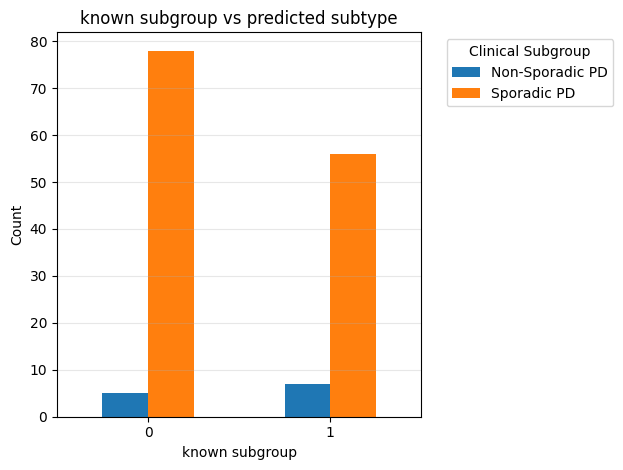

In [5]:
# Clinical Subgroup Comparison: All Subgroup Types
# Get unique patient IDs and their subgroup assignments
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            # Take most common subgroup if multiple
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Get all unique subgroup types
all_subgroups = np.unique(subgroup_per_patient)
print(f"\nAll subgroup types found: {all_subgroups}")

# Create contingency table with all subgroup types
contingency_all = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(subgroup_per_patient, name='Clinical Subgroup')
)
print("\n=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===")
print(contingency_all)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_all)
print(f"\nChi-square test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot all subgroups
plt.figure(figsize=(12, 6))
contingency_all.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs All Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Also create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup_binary = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table for binary
contingency_binary = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup_binary, name='Clinical Subgroup')
)
print(contingency_binary)

# Chi-square test for binary
chi2_binary, p_value_binary, dof_binary, expected_binary = chi2_contingency(contingency_binary)
print(f"\nChi-square test (binary):")
print(f"  χ² = {chi2_binary:.4f}")
print(f"  p-value = {p_value_binary:.4f}")
print(f"  df = {dof_binary}")

# Plot binary
plt.figure(figsize=(10, 6))
contingency_binary.plot(kind='bar', stacked=False)
plt.title('known subgroup vs predicted subtype')
plt.xlabel('known subgroup')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 1:
  Intercept (cog_b): 10.9672
  MCATOT coefficient: 0.1489
  TD_score coefficient: -0.1827
  PIGD_score coefficient: 0.1227
s_ij = 10.9672 +0.1489 * MCATOT +-0.1827 * TD +0.1227 * PIGD

Subtype 2:
  Intercept (cog_b): 17.8829
  MCATOT coefficient: -0.0235
  TD_score coefficient: -0.0769
  PIGD_score coefficient: 0.2997
s_ij = 17.8829 +-0.0235 * MCATOT +-0.0769 * TD +0.2997 * PIGD


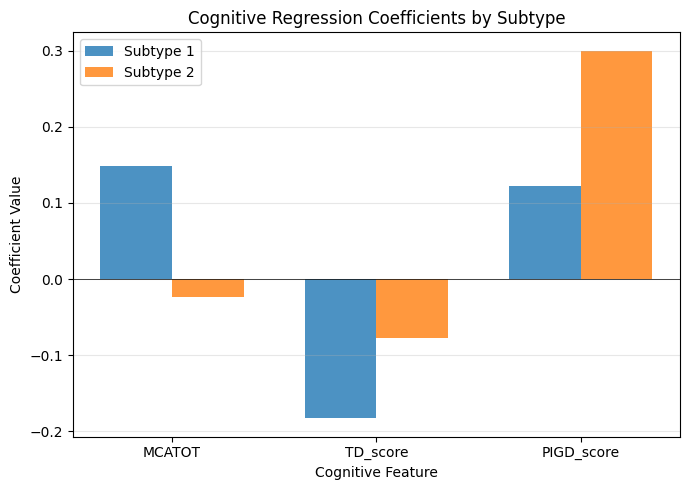

In [6]:
# Cognitive Parameter Comparison
cluster_cog_a = best_data["cluster_cog_a"]  # (n_subtypes, n_cog_features)
cluster_cog_b = best_data["cluster_cog_b"]  # (n_subtypes,)

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype + 1}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


# Plot comparison (single plot for cognitive scores)
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(cog_feature_names))
width = 0.35
ax.bar(x - width/2, cluster_cog_a[0], width, label='Subtype 1', alpha=0.8)
ax.bar(x + width/2, cluster_cog_a[1], width, label='Subtype 2', alpha=0.8)
ax.set_xlabel('Cognitive Feature')
ax.set_ylabel('Coefficient Value')
ax.set_title('Cognitive Regression Coefficients by Subtype')
ax.set_xticks(x)
ax.set_xticklabels(cog_feature_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

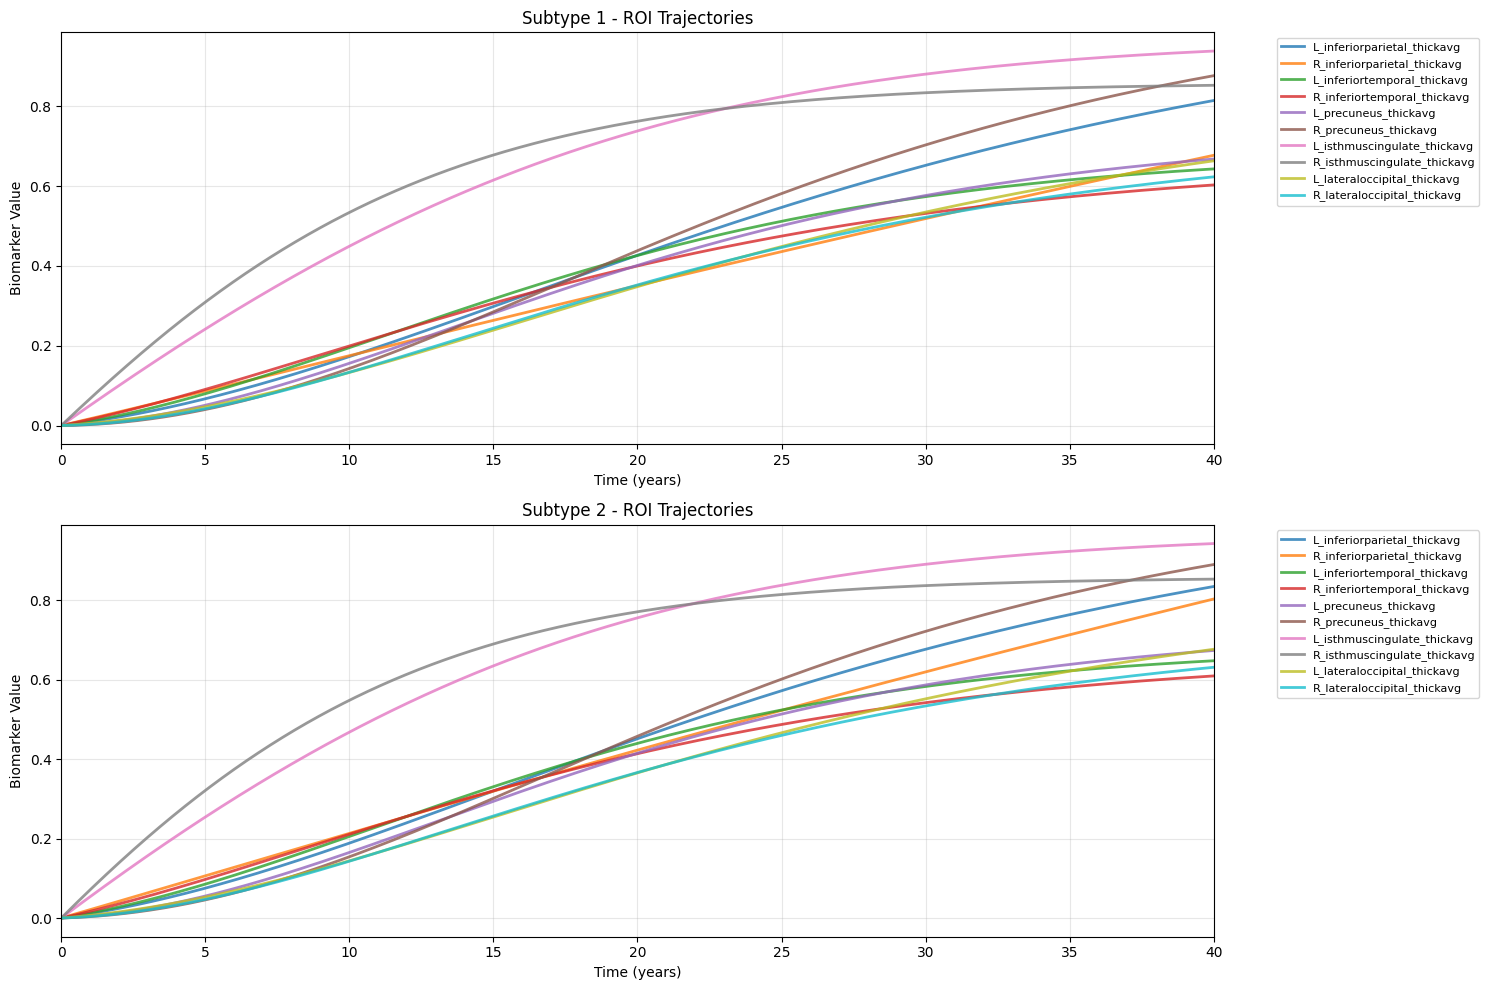

In [7]:
# ROI Subplots: 10 ROI trajectories for each subtype
ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype + 1} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()


In [8]:
# # Plot all 68 brain regions for both subtypes
# cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
# n_subtypes = cluster_f.shape[0]
# n_biomarkers = cluster_f.shape[1]

# final_scalar_K = best_data["final_scalar_K"]
# final_s = best_data["final_s"]

# # Get biomarker names
# biomarker_names = [col for col in df.columns 
#                    if col.startswith(('L_', 'R_')) and 
#                    col.endswith('_thickavg') and 
#                    not col.endswith('_thickavg_resid')]

# # Create a grid layout for all 68 regions
# # Use 9 rows x 8 columns = 72 subplots (we'll use 68)
# n_rows = 9
# n_cols = 8

# # Create figure with subplots for each subtype
# fig, axes = plt.subplots(n_subtypes, 1, figsize=(20, 6*n_subtypes))
# if n_subtypes == 1:
#     axes = [axes]

# for subtype in range(n_subtypes):
#     f_subtype = cluster_f[subtype]
#     x0 = np.zeros(n_biomarkers)
#     Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
#     # Create a grid of subplots for this subtype
#     fig_subtype, axes_grid = plt.subplots(n_rows, n_cols, figsize=(20, 22))
#     axes_grid = axes_grid.flatten()
    
#     for region_idx in range(n_biomarkers):
#         ax = axes_grid[region_idx]
#         ax.plot(t_span, Xtraj_subtype[region_idx], linewidth=1.5, alpha=0.8, color='steelblue' if subtype == 0 else 'coral')
#         ax.set_title(biomarker_names[region_idx], fontsize=7, pad=2)
#         ax.set_xlim(0, t_max)
#         ax.grid(True, alpha=0.2)
#         ax.tick_params(labelsize=6)
        
#         # Only show xlabel on bottom row
#         if region_idx >= n_biomarkers - n_cols:
#             ax.set_xlabel('Time (years)', fontsize=7)
#         # Only show ylabel on leftmost column
#         if region_idx % n_cols == 0:
#             ax.set_ylabel('Value', fontsize=7)
    
#     # Hide unused subplots
#     for idx in range(n_biomarkers, n_rows * n_cols):
#         axes_grid[idx].axis('off')
    
#     plt.suptitle(f'Subtype {subtype} - All 68 Brain Region Trajectories', fontsize=16, y=0.995)
#     plt.tight_layout(rect=[0, 0, 1, 0.99])
#     plt.show()

# # Also create a comparison plot showing both subtypes overlaid for all regions
# fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(20, 22))
# axes_grid = axes_grid.flatten()

# # Compute trajectories for both subtypes
# Xtraj_subtype0 = solve_system(np.zeros(n_biomarkers), cluster_f[0], K, t_span, final_scalar_K) * final_s[:, None]
# Xtraj_subtype1 = solve_system(np.zeros(n_biomarkers), cluster_f[1], K, t_span, final_scalar_K) * final_s[:, None]

# for region_idx in range(n_biomarkers):
#     ax = axes_grid[region_idx]
#     ax.plot(t_span, Xtraj_subtype0[region_idx], linewidth=1.5, alpha=0.7, color='steelblue', label='Subtype 0')
#     ax.plot(t_span, Xtraj_subtype1[region_idx], linewidth=1.5, alpha=0.7, color='coral', label='Subtype 1')
#     ax.set_title(biomarker_names[region_idx], fontsize=7, pad=2)
#     ax.set_xlim(0, t_max)
#     ax.grid(True, alpha=0.2)
#     ax.tick_params(labelsize=6)
    
#     # Only show xlabel on bottom row
#     if region_idx >= n_biomarkers - n_cols:
#         ax.set_xlabel('Time (years)', fontsize=7)
#     # Only show ylabel on leftmost column
#     if region_idx % n_cols == 0:
#         ax.set_ylabel('Value', fontsize=7)
    
#     # Add legend only to first subplot
#     if region_idx == 0:
#         ax.legend(fontsize=6, loc='upper right')

# # Hide unused subplots
# for idx in range(n_biomarkers, n_rows * n_cols):
#     axes_grid[idx].axis('off')

# plt.suptitle('Comparison: All 68 Brain Region Trajectories (Subtype 0 vs Subtype 1)', fontsize=16, y=0.995)
# plt.tight_layout(rect=[0, 0, 1, 0.99])
# plt.show()



CONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 5           78
1                                 7           56

Chi-squared = 0.6468
  p-value = 0.4213
  df = 1


<Figure size 1000x600 with 0 Axes>

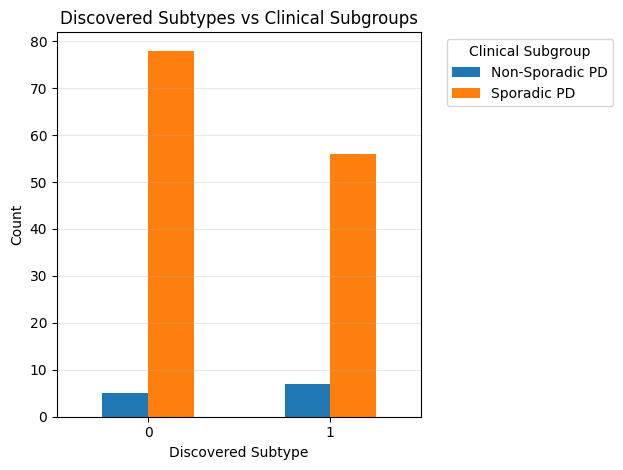

In [9]:
# Clinical Subgroup Comparison: Sporadic PD vs Non-Sporadic PD
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table
contingency = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup, name='Clinical Subgroup')
)
print("\nCONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-squared = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot
plt.figure(figsize=(10, 6))
contingency.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 1 Beta Statistics:
  Mean: 12.8620
  Median: 12.8223
  Std: 0.8970

Subtype 2 Beta Statistics:
  Mean: 15.6428
  Median: 15.6883
  Std: 1.0919


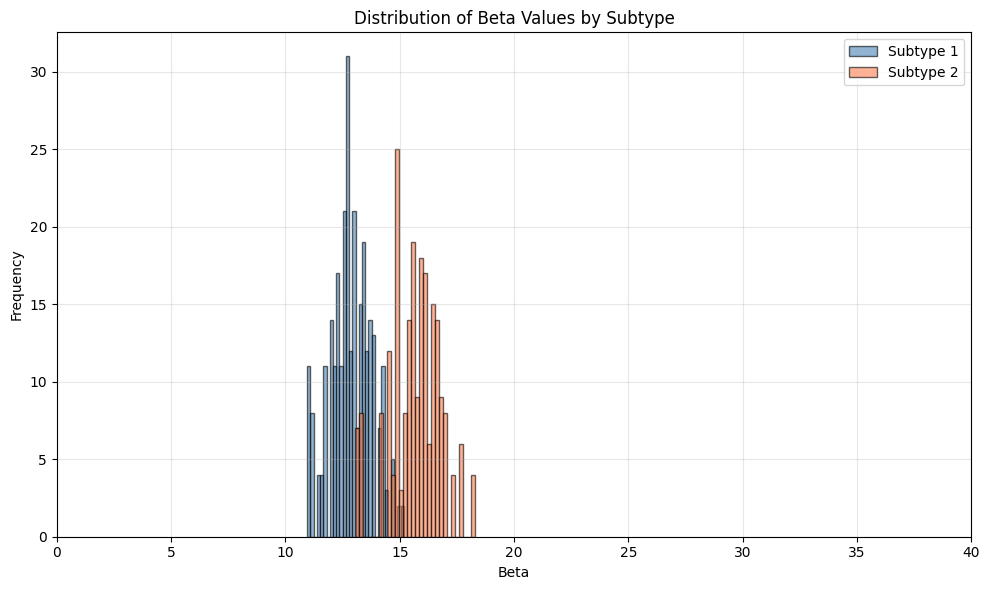

In [10]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype + 1}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype + 1} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")
plt.xlim(0, 40)
plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# # Plot assignment history over iterations
# if "assignment_history" in best_data.files:
#     assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
#     n_iterations = assignment_history.shape[1] - 1
    
#     # Calculate percentage of subtype 0 and 1 for each iteration
#     pct_subtype0 = []
#     pct_subtype1 = []
    
#     for iter_idx in range(n_iterations + 1):
#         assignments_iter = assignment_history[:, iter_idx]
#         n_patients = len(assignments_iter)
#         n_subtype0 = np.sum(assignments_iter == 0)
#         n_subtype1 = np.sum(assignments_iter == 1)
        
#         pct_subtype0.append(100 * n_subtype0 / n_patients)
#         pct_subtype1.append(100 * n_subtype1 / n_patients)
    
#     # Plot
#     plt.figure(figsize=(12, 6))
#     iterations = np.arange(n_iterations + 1)
#     plt.plot(iterations, pct_subtype0, label='Subtype 0', linewidth=2, marker='o', markersize=4)
#     plt.plot(iterations, pct_subtype1, label='Subtype 1', linewidth=2, marker='s', markersize=4)
#     plt.xlabel('Iteration')
#     plt.ylabel('Percentage of Patients (%)')
#     plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.ylim(0, 100)
#     plt.tight_layout()
#     plt.show()
    
#     print(f"\nAssignment History Summary:")
#     print(f"  Initial - Subtype 0: {pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[0]:.1f}%")
#     print(f"  Final   - Subtype 0: {pct_subtype0[-1]:.1f}%, Subtype 1: {pct_subtype1[-1]:.1f}%")
#     print(f"  Change  - Subtype 0: {pct_subtype0[-1] - pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[-1] - pct_subtype1[0]:.1f}%")
# else:
#     print("Assignment history not available in best_data")


=== Relative Difference Analysis ===
Overall max absolute forcing term: 2.8638
Threshold (5% of max): 0.1432
Regions above threshold: 6/68


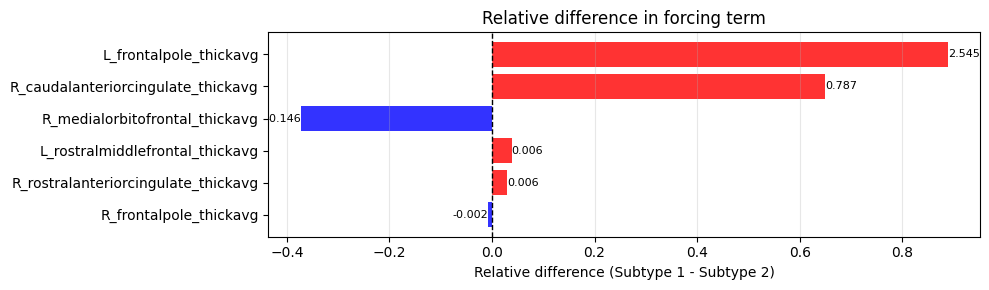


Top 6 regions with largest relative differences (filtered):
  1. L_frontalpole_thickavg:
      Relative diff: 0.8887
      Absolute diff: 2.5452
      Subtype 1: 2.8638, Subtype 2: 0.3186
      Max(|f1|,|f2|): 2.8638
  2. R_caudalanteriorcingulate_thickavg:
      Relative diff: 0.6498
      Absolute diff: 0.7867
      Subtype 1: 1.2108, Subtype 2: 0.4241
      Max(|f1|,|f2|): 1.2108
  3. R_medialorbitofrontal_thickavg:
      Relative diff: -0.3729
      Absolute diff: -0.1464
      Subtype 1: 0.2461, Subtype 2: 0.3925
      Max(|f1|,|f2|): 0.3925
  4. L_rostralmiddlefrontal_thickavg:
      Relative diff: 0.0381
      Absolute diff: 0.0057
      Subtype 1: 0.1489, Subtype 2: 0.1432
      Max(|f1|,|f2|): 0.1489
  5. R_rostralanteriorcingulate_thickavg:
      Relative diff: 0.0299
      Absolute diff: 0.0060
      Subtype 1: 0.2000, Subtype 2: 0.1940
      Max(|f1|,|f2|): 0.2000
  6. R_frontalpole_thickavg:
      Relative diff: -0.0079
      Absolute diff: -0.0024
      Subtype 1: 0.3064

In [12]:
# Compare forcing terms (f) between subtypes for all 68 brain regions
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

f_subtype1 = cluster_f[0]  # (68,) - Subtype 1 (was 0)
f_subtype2 = cluster_f[1]  # (68,) - Subtype 2 (was 1)

# Get biomarker names
biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Compute differences
f_diff = f_subtype1 - f_subtype2

# Relative difference: (f1 - f2) / max(|f1|, |f2|)
max_abs_per_region = np.maximum(np.abs(f_subtype1), np.abs(f_subtype2))
overall_max_abs = np.max(max_abs_per_region)

relative_diff = np.zeros(n_biomarkers)
for i in range(n_biomarkers):
    max_abs_i = max_abs_per_region[i]
    if max_abs_i > 1e-10:  # Avoid division by zero
        relative_diff[i] = f_diff[i] / max_abs_i
    else:
        relative_diff[i] = 0.0

# Filter threshold: only show regions where max(|f0|, |f1|) >= threshold * overall_max
threshold_fraction = 0.05  # 5% of overall max
threshold_value = threshold_fraction * overall_max_abs
valid_mask = max_abs_per_region >= threshold_value
valid_indices = np.where(valid_mask)[0]

print(f"=== Relative Difference Analysis ===")
print(f"Overall max absolute forcing term: {overall_max_abs:.4f}")
print(f"Threshold (5% of max): {threshold_value:.4f}")
print(f"Regions above threshold: {len(valid_indices)}/{n_biomarkers}")

# Bar chart showing relative differences for filtered regions (top 20 by |relative diff|)
relative_diff_filtered = relative_diff[valid_indices]
relative_diff_abs_filtered = np.abs(relative_diff_filtered)
top_n_rel = min(20, len(valid_indices))  # Show top 20 or all if fewer
top_indices_rel = np.argsort(relative_diff_abs_filtered)[-top_n_rel:][::-1]
top_indices_rel_original = valid_indices[top_indices_rel]

fig, ax = plt.subplots(figsize=(10, 3))
x_pos = np.arange(len(top_indices_rel_original))
colors_bar_rel = ['red' if relative_diff[idx] > 0 else 'blue' for idx in top_indices_rel_original]
bars = ax.barh(x_pos, relative_diff[top_indices_rel_original], color=colors_bar_rel, alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels([biomarker_names[idx] for idx in top_indices_rel_original])
ax.set_xlabel('Relative difference (Subtype 1 - Subtype 2)')
ax.set_title('Relative difference in forcing term')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()  # Show largest differences at top

# Add text labels with actual (absolute) difference on each bar
for i, (idx, bar) in enumerate(zip(top_indices_rel_original, bars)):
    abs_diff_val = f_diff[idx]
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{abs_diff_val:.3f}',
            ha='left' if width > 0 else 'right',
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop {top_n_rel} regions with largest relative differences (filtered):")
for i, idx in enumerate(top_indices_rel_original):
    max_abs_i = max_abs_per_region[idx]
    rel_diff_i = relative_diff[idx]
    print(f"  {i+1}. {biomarker_names[idx]}:")
    print(f"      Relative diff: {rel_diff_i:.4f}")
    print(f"      Absolute diff: {f_diff[idx]:.4f}")
    print(f"      Subtype 1: {f_subtype1[idx]:.4f}, Subtype 2: {f_subtype2[idx]:.4f}")
    print(f"      Max(|f1|,|f2|): {max_abs_i:.4f}")


In [13]:
top10_df = summary_df.head(10)
display_cols = ["candidate", "final_lse", "scalar_K", "mean_s", "subtype0_count", "subtype1_count"]
if all(col in top10_df.columns for col in display_cols):
    print(top10_df[display_cols].to_string(index=False))
else:
    print(top10_df)


candidate  final_lse             scalar_K   mean_s  subtype0_count  subtype1_count
      103 611.743849  0.04325942507541538 0.949596              60              56
       23 694.417638 0.030131337810075296 0.907538              65              51
        3 699.863852 0.037723024643891365 0.924450              65              51
        7 703.962317  0.03673380232781289 0.929452              63              53
       11 707.294226 0.018134616890483776 0.850091              63              53
        0 720.967400  0.13590192707502136 0.497770              65              51
        5 722.113326  0.13336706490728228 0.498595              65              51
        9 722.302897  0.13256054764192648 0.498473              65              51
       50 723.562684  0.14310095798749373 0.498293              65              51
       12 726.570777   0.1451979842385529 0.494489              63              53


In [14]:
# Save forcing terms (time-invariant f) and trajectories at selected times

cluster_f = best_data["cluster_f"]  # shape: (n_subtypes, n_biomarkers)
final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

n_subtypes, n_biomarkers = cluster_f.shape

# ---------- 1) Save forcing terms per subtype ----------
forcing_out_path = os.path.join(result_dir, "forcing_terms_best_model.npz")
np.savez(
    forcing_out_path,
    cluster_f=cluster_f,                 # (n_subtypes, n_biomarkers)
    biomarker_names=np.array(biomarker_names),
    n_subtypes=n_subtypes,
)
print("Saved forcing terms to:", forcing_out_path)

# ---------- 2) Save trajectories at selected times ----------
# Time points of interest in years
selected_times = np.array([10.0, 20.0, 30.0, 40.0])

# Find indices in t_span closest to the selected times
selected_indices = np.array([np.argmin(np.abs(t_span - t)) for t in selected_times])
print("Selected times (years, snapped to grid):", t_span[selected_indices])

# Allocate array: (n_subtypes, n_biomarkers, n_selected_times)
trajectories_at_times = np.zeros((n_subtypes, n_biomarkers, len(selected_indices)))

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    trajectories_at_times[subtype] = Xtraj_subtype[:, selected_indices]

traj_out_path = os.path.join(result_dir, "trajectories_t10_20_30_40_best_model.npz")
np.savez(
    traj_out_path,
    trajectories_at_times=trajectories_at_times,  # (n_subtypes, n_biomarkers, 4)
    selected_times=t_span[selected_indices],
    biomarker_names=np.array(biomarker_names),
    n_subtypes=n_subtypes,
)
print("Saved trajectories to:", traj_out_path)

Saved forcing terms to: /home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_gridsearch_refined_fine/forcing_terms_best_model.npz
Selected times (years, snapped to grid): [10.00250063 19.99499875 29.99749937 40.        ]
Saved trajectories to: /home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_gridsearch_refined_fine/trajectories_t10_20_30_40_best_model.npz


In [15]:
# Inspect saved forcing-term and trajectory files
forcing_path = os.path.join(result_dir, "forcing_terms_best_model.npz")
traj_path = os.path.join(result_dir, "trajectories_t10_20_30_40_best_model.npz")

forcing_data = np.load(forcing_path, allow_pickle=True)
traj_data = np.load(traj_path, allow_pickle=True)

print("Forcing terms file:")
for key in forcing_data.files:
    arr = forcing_data[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

print("\nTrajectories file:")
for key in traj_data.files:
    arr = traj_data[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")


Forcing terms file:
  cluster_f: shape=(2, 68), dtype=float64
  biomarker_names: shape=(68,), dtype=<U35
  n_subtypes: shape=(), dtype=int64

Trajectories file:
  trajectories_at_times: shape=(2, 68, 4), dtype=float64
  selected_times: shape=(4,), dtype=float64
  biomarker_names: shape=(68,), dtype=<U35
  n_subtypes: shape=(), dtype=int64


In [16]:
# # Comparison plot: all 68 trajectories, both subtypes overlaid
# cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
# n_subtypes, n_biomarkers = cluster_f.shape

# final_scalar_K = best_data["final_scalar_K"]
# final_s = best_data["final_s"]

# # Sanity check
# print(f"n_subtypes = {n_subtypes}, n_biomarkers = {n_biomarkers}")

# # Compute trajectories for both subtypes
# Xtraj_subtype0 = solve_system(np.zeros(n_biomarkers), cluster_f[0], K, t_span, final_scalar_K) * final_s[:, None]
# Xtraj_subtype1 = solve_system(np.zeros(n_biomarkers), cluster_f[1], K, t_span, final_scalar_K) * final_s[:, None]

# # Grid layout: 9x8 = 72 slots, we use 68
# n_rows, n_cols = 9, 8
# fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(20, 22))
# axes_grid = axes_grid.flatten()

# for region_idx in range(n_biomarkers):
#     ax = axes_grid[region_idx]
#     ax.plot(t_span, Xtraj_subtype0[region_idx], linewidth=1.5, alpha=0.7,
#             color='steelblue', label='Subtype 1')
#     ax.plot(t_span, Xtraj_subtype1[region_idx], linewidth=1.5, alpha=0.7,
#             color='coral', label='Subtype 2')
#     ax.set_title(biomarker_names[region_idx], fontsize=7, pad=2)
#     ax.set_xlim(0, t_max)
#     ax.grid(True, alpha=0.2)
#     ax.tick_params(labelsize=6)

#     # Only show xlabel on bottom row
#     if region_idx >= n_biomarkers - n_cols:
#         ax.set_xlabel('Time (years)', fontsize=7)
#     # Only show ylabel on leftmost column
#     if region_idx % n_cols == 0:
#         ax.set_ylabel('Value', fontsize=7)

#     # Add legend only to the first subplot
#     if region_idx == 0:
#         ax.legend(fontsize=6, loc='upper right')

# # Hide unused subplots, if any
# for idx in range(n_biomarkers, n_rows * n_cols):
#     axes_grid[idx].axis('off')

# plt.suptitle('All 68 brain regions: trajectories for both subtypes', fontsize=16, y=0.995)
# plt.tight_layout(rect=[0, 0, 1, 0.99])
# plt.show()


Top 10 regions with largest relative differences in f:
  1. L_frontalpole_thickavg: 0.8887
  2. R_caudalanteriorcingulate_thickavg: 0.6498
  3. R_medialorbitofrontal_thickavg: -0.3729
  4. L_caudalanteriorcingulate_thickavg: -0.0734
  5. L_insula_thickavg: -0.0727
  6. L_parsorbitalis_thickavg: -0.0668
  7. R_parstriangularis_thickavg: -0.0629
  8. R_parsopercularis_thickavg: -0.0587
  9. L_rostralmiddlefrontal_thickavg: 0.0381
  10. R_rostralanteriorcingulate_thickavg: 0.0299


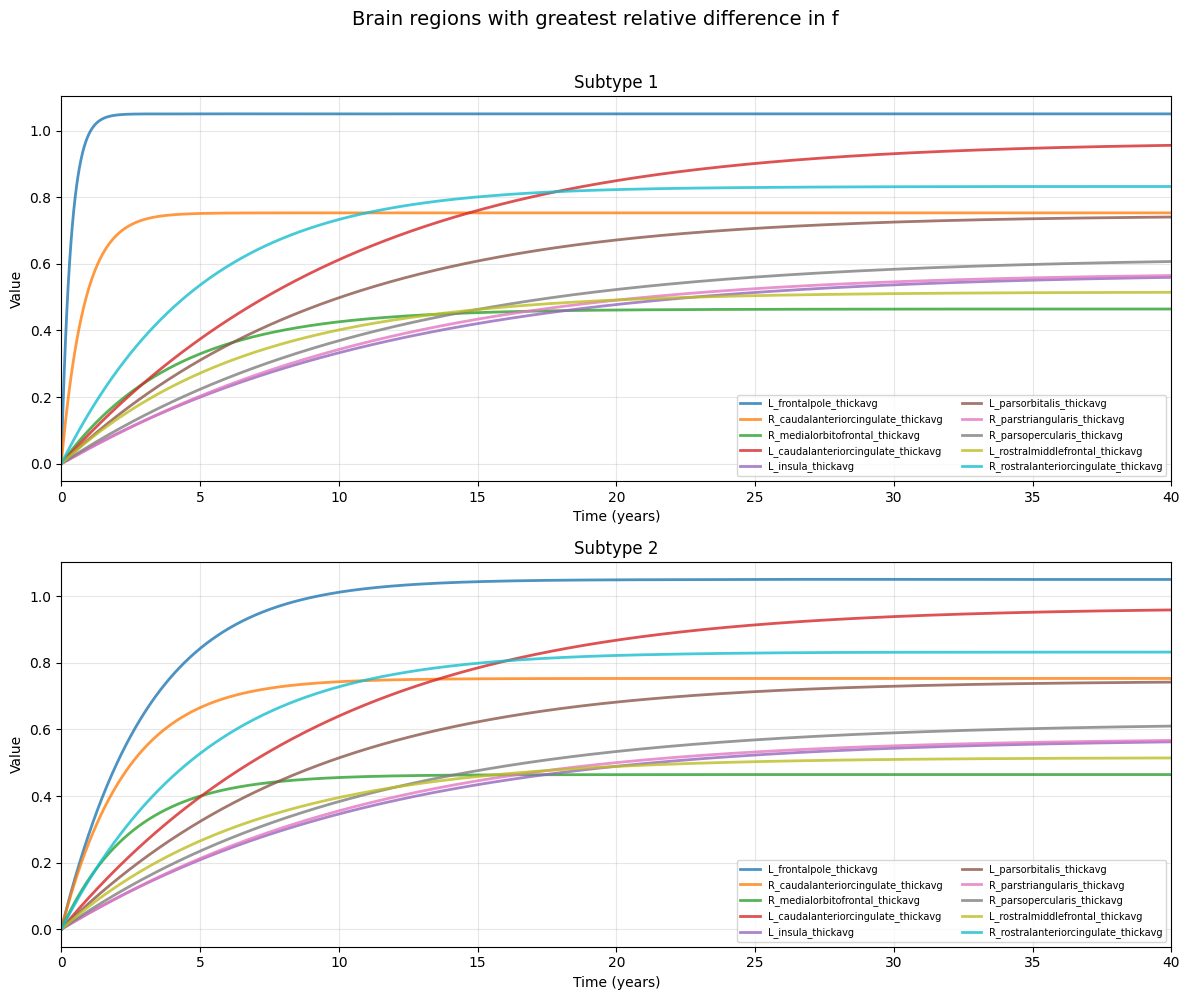

In [17]:
# Top 10 regions with largest relative differences in f: 2x1 subplot with tab10 colors
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes, n_biomarkers = cluster_f.shape

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

f_subtype1 = cluster_f[0]  # Subtype 1 (was 0)
f_subtype2 = cluster_f[1]  # Subtype 2 (was 1)
f_diff = f_subtype1 - f_subtype2

# Compute relative differences (same as Cell 11)
max_abs_per_region = np.maximum(np.abs(f_subtype1), np.abs(f_subtype2))
overall_max_abs = np.max(max_abs_per_region)

relative_diff = np.zeros(n_biomarkers)
for i in range(n_biomarkers):
    max_abs_i = max_abs_per_region[i]
    if max_abs_i > 1e-10:  # Avoid division by zero
        relative_diff[i] = f_diff[i] / max_abs_i
    else:
        relative_diff[i] = 0.0

# Apply same filtering threshold as Cell 11: only regions where max(|f1|,|f2|) >= threshold * overall_max
threshold_fraction = 0.03  # 5% of overall max
threshold_value = threshold_fraction * overall_max_abs
valid_mask = max_abs_per_region >= threshold_value
valid_indices = np.where(valid_mask)[0]

# Find top 10 from filtered regions by absolute relative difference
relative_diff_filtered = relative_diff[valid_indices]
relative_diff_abs_filtered = np.abs(relative_diff_filtered)
top_n = min(10, len(valid_indices))  # Show top 10 or all if fewer
top_indices_filtered = np.argsort(relative_diff_abs_filtered)[-top_n:][::-1]
top_10_indices = valid_indices[top_indices_filtered]

print("Top 10 regions with largest relative differences in f:")
for i, idx in enumerate(top_10_indices):
    print(f"  {i+1}. {biomarker_names[idx]}: {relative_diff[idx]:.4f}")

# Compute trajectories for both subtypes
Xtraj_subtype1 = solve_system(np.zeros(n_biomarkers), cluster_f[0], K, t_span, final_scalar_K) * final_s[:, None]
Xtraj_subtype2 = solve_system(np.zeros(n_biomarkers), cluster_f[1], K, t_span, final_scalar_K) * final_s[:, None]

# Get tab10 color palette
tab10_colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Create 2x1 subplot (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top subplot: Subtype 1 trajectories for all 10 regions
ax_top = axes[0]
for plot_idx, region_idx in enumerate(top_10_indices):
    ax_top.plot(t_span, Xtraj_subtype1[region_idx], linewidth=2, alpha=0.8,
                color=tab10_colors[plot_idx], label=biomarker_names[region_idx])
ax_top.set_xlim(0, t_max)
ax_top.set_xlabel('Time (years)', fontsize=10)
ax_top.set_ylabel('Value', fontsize=10)
ax_top.set_title('Subtype 1', fontsize=12)
ax_top.grid(True, alpha=0.3)
ax_top.legend(fontsize=7, loc='best', ncol=2)

# Bottom subplot: Subtype 2 trajectories for the same 10 regions
ax_bottom = axes[1]
for plot_idx, region_idx in enumerate(top_10_indices):
    ax_bottom.plot(t_span, Xtraj_subtype2[region_idx], linewidth=2, alpha=0.8,
                   color=tab10_colors[plot_idx], label=biomarker_names[region_idx])
ax_bottom.set_xlim(0, t_max)
ax_bottom.set_xlabel('Time (years)', fontsize=10)
ax_bottom.set_ylabel('Value', fontsize=10)
ax_bottom.set_title('Subtype 2', fontsize=12)
ax_bottom.grid(True, alpha=0.3)
ax_bottom.legend(fontsize=7, loc='best', ncol=2)

plt.suptitle("Brain regions with greatest relative difference in f", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


/tmp/ipykernel_23645/2845879699.py:28: RuntimeWarning: Mean of empty slice
  pid_to_nsd[pid] = np.nanmean(nsd_pid)


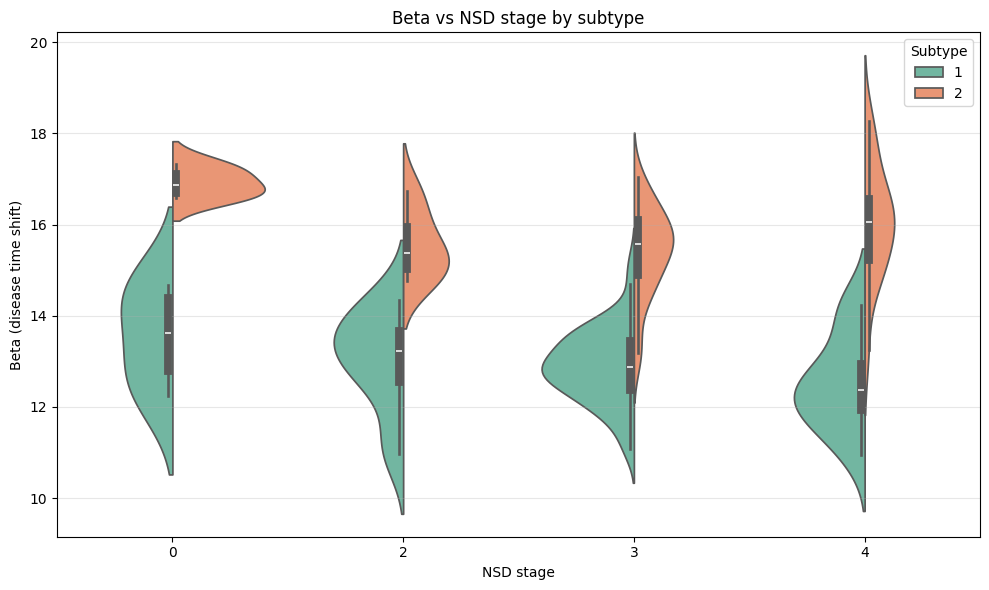

/tmp/ipykernel_23645/2845879699.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_td.boxplot([sub1['TD'], sub2['TD']], labels=['Subtype 1', 'Subtype 2'])
/tmp/ipykernel_23645/2845879699.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_pigd.boxplot([sub1['PIGD'], sub2['PIGD']], labels=['Subtype 1', 'Subtype 2'])
/tmp/ipykernel_23645/2845879699.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_moca.boxplot([sub1['MoCA'], sub2['MoCA']], labels=['Subtype 1', 'Subtype 2'])


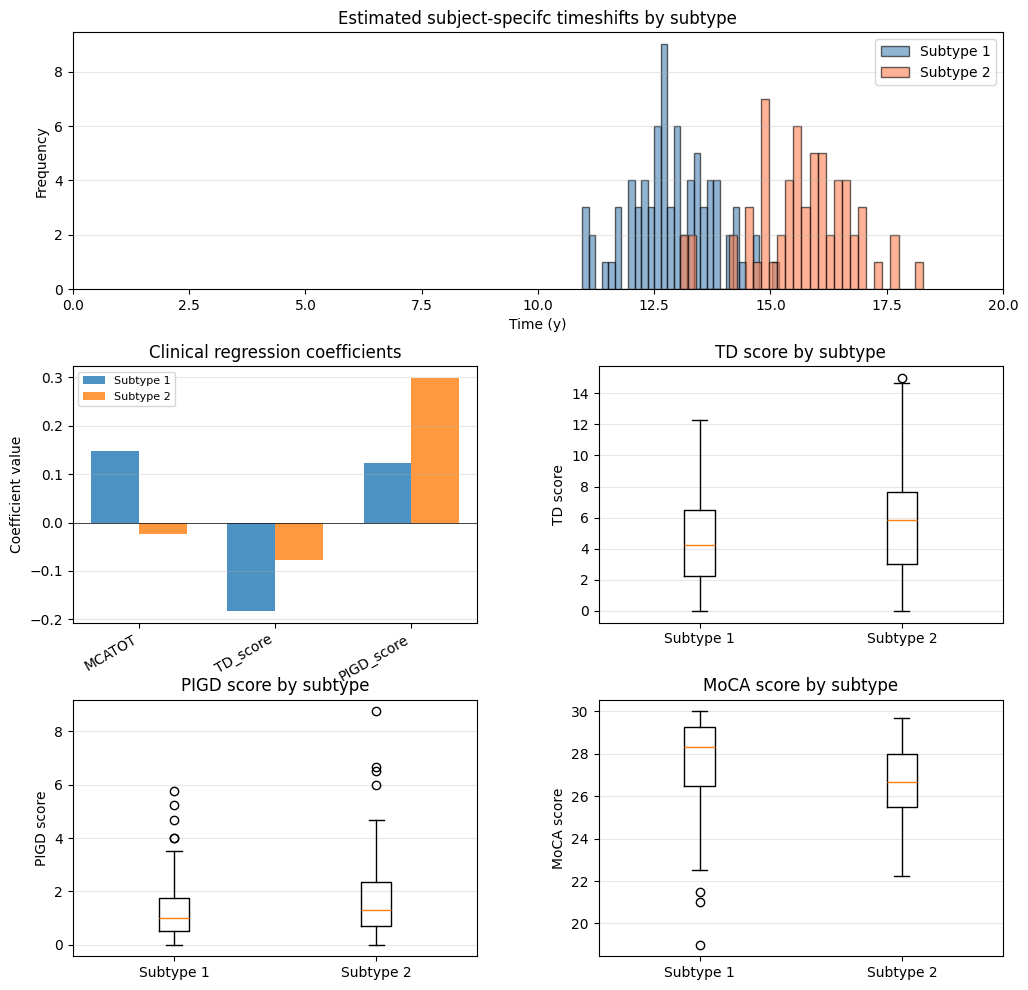

In [18]:
# Violin plot: beta vs initial H&Y (NHY) by subtype, and 2x2 panel of cognitive relationships

# --- Build patient-level table with beta, initial NHY, subtype, and MoCA/TD/PIGD ---
unique_pids = np.unique(ids_valid)

pid_to_beta = {}
pid_to_nhy_init = {}
pid_to_nsd = {}
pid_to_td = {}
pid_to_pigd = {}
pid_to_moca = {}

for pid in unique_pids:
    mask_all = (ids_all == pid)
    if mask_all.sum() == 0:
        continue
    # beta: take first matched beta_valid entry for this pid
    mask_valid = (ids_valid == pid)
    if mask_valid.any():
        pid_to_beta[pid] = float(beta_valid[mask_valid][0])
    # initial H&Y: earliest visit by dt
    dt_pid = dt_all[mask_all]
    nhy_pid = nhy_all[mask_all]
    idx0 = np.argmin(dt_pid)
    pid_to_nhy_init[pid] = nhy_pid[idx0]
    # NSD stage: average across visits (could also use baseline)
    nsd_pid = nsd[mask_all]
    pid_to_nsd[pid] = np.nanmean(nsd_pid)
    # TD, PIGD, MoCA (average across visits)
    cog_pid = cog_all[mask_all]
    pid_to_moca[pid] = np.nanmean(cog_pid[:, 0])
    pid_to_td[pid]   = np.nanmean(cog_pid[:, 1])
    pid_to_pigd[pid] = np.nanmean(cog_pid[:, 2])

rows = []
for pid in unique_pids:
    assignment = pid_to_assignment.get(pid, -1)
    if assignment < 0:
        continue
    if pid not in pid_to_beta or pid not in pid_to_nhy_init or pid not in pid_to_nsd:
        continue
    nhy_val = pid_to_nhy_init[pid]
    nsd_val = pid_to_nsd[pid]
    if np.isnan(nhy_val) or np.isnan(nsd_val):
        continue
    rows.append({
        'pid': pid,
        'Subtype': assignment + 1,  # 1 or 2
        'beta': pid_to_beta[pid],
        'NHY_init': int(nhy_val),
        'NSD_stage': int(round(nsd_val)),
        'MoCA': pid_to_moca[pid],
        'TD': pid_to_td[pid],
        'PIGD': pid_to_pigd[pid],
    })

patient_df = pd.DataFrame(rows)

# --- Violin plot: beta vs NSD stage, separated by subtype ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=patient_df,
    x='NSD_stage',
    y='beta',
    hue='Subtype',
    split=True,
    inner='box',
    palette='Set2'
)
plt.xlabel('NSD stage')
plt.ylabel('Beta (disease time shift)')
plt.title('Beta vs NSD stage by subtype')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- 3x2 subplot: beta distributions + cognitive coefficients + clinical score boxplots ---

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# Prepare arrays from patient_df grouped by subtype
sub1 = patient_df[patient_df['Subtype'] == 1]
sub2 = patient_df[patient_df['Subtype'] == 2]

# Top row: Beta distributions by subtype (spans 2 columns) - histogram
ax_beta = fig.add_subplot(gs[0, :])
ax_beta.hist(sub1['beta'], bins=30, alpha=0.6, label='Subtype 1', color='steelblue', edgecolor='black')
ax_beta.hist(sub2['beta'], bins=30, alpha=0.6, label='Subtype 2', color='coral', edgecolor='black')
ax_beta.set_xlabel('Time (y)')
ax_beta.set_ylabel('Frequency')
ax_beta.set_title('Estimated subject-specifc timeshifts by subtype')
ax_beta.legend()
ax_beta.grid(True, alpha=0.3, axis='y')
ax_beta.set_xlim(0, 20)

# Middle row: (1, 0) Cognitive regression coefficients
x = np.arange(len(cog_feature_names))
width = 0.35
ax_cog = fig.add_subplot(gs[1, 0])
ax_cog.bar(x - width/2, cluster_cog_a[0], width, label='Subtype 1', alpha=0.8)
ax_cog.bar(x + width/2, cluster_cog_a[1], width, label='Subtype 2', alpha=0.8)
#ax_cog.set_xlabel('Clinical Feature')
ax_cog.set_ylabel('Coefficient value')
ax_cog.set_title('Clinical regression coefficients')
ax_cog.set_xticks(x)
ax_cog.set_xticklabels(cog_feature_names, rotation=30, ha='right')
ax_cog.legend(fontsize=8)
ax_cog.grid(True, alpha=0.3, axis='y')
ax_cog.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Middle row: (1, 1) TD boxplot
ax_td = fig.add_subplot(gs[1, 1])
ax_td.boxplot([sub1['TD'], sub2['TD']], labels=['Subtype 1', 'Subtype 2'])
ax_td.set_ylabel('TD score')
ax_td.set_title('TD score by subtype')
ax_td.grid(True, alpha=0.3, axis='y')

# Bottom row: (2, 0) PIGD boxplot
ax_pigd = fig.add_subplot(gs[2, 0])
ax_pigd.boxplot([sub1['PIGD'], sub2['PIGD']], labels=['Subtype 1', 'Subtype 2'])
ax_pigd.set_ylabel('PIGD score')
ax_pigd.set_title('PIGD score by subtype')
ax_pigd.grid(True, alpha=0.3, axis='y')

# Bottom row: (2, 1) MoCA boxplot
ax_moca = fig.add_subplot(gs[2, 1])
ax_moca.boxplot([sub1['MoCA'], sub2['MoCA']], labels=['Subtype 1', 'Subtype 2'])
ax_moca.set_ylabel('MoCA score')
ax_moca.set_title('MoCA score by subtype')
ax_moca.grid(True, alpha=0.3, axis='y')

plt.show()


=== TD Score Comparison ===
Subtype 1: mean=4.406, median=4.000, std=3.074
Subtype 2: mean=5.808, median=5.750, std=3.475

=== PIGD Score Comparison ===
Subtype 1: mean=1.288, median=1.000, std=1.194
Subtype 2: mean=1.810, median=1.333, std=1.693

=== TD Score Statistical Tests ===
t-test: t=-2.563, p=0.0114
Mann-Whitney U: U=1981.5, p=0.0124
Expected: Subtype 1 should have higher TD scores (more tremor-dominant)

=== PIGD Score Statistical Tests ===
t-test: t=-2.166, p=0.0319
Mann-Whitney U: U=2095.5, p=0.0400
Expected: Subtype 2 should have higher PIGD scores (more postural/gait issues)


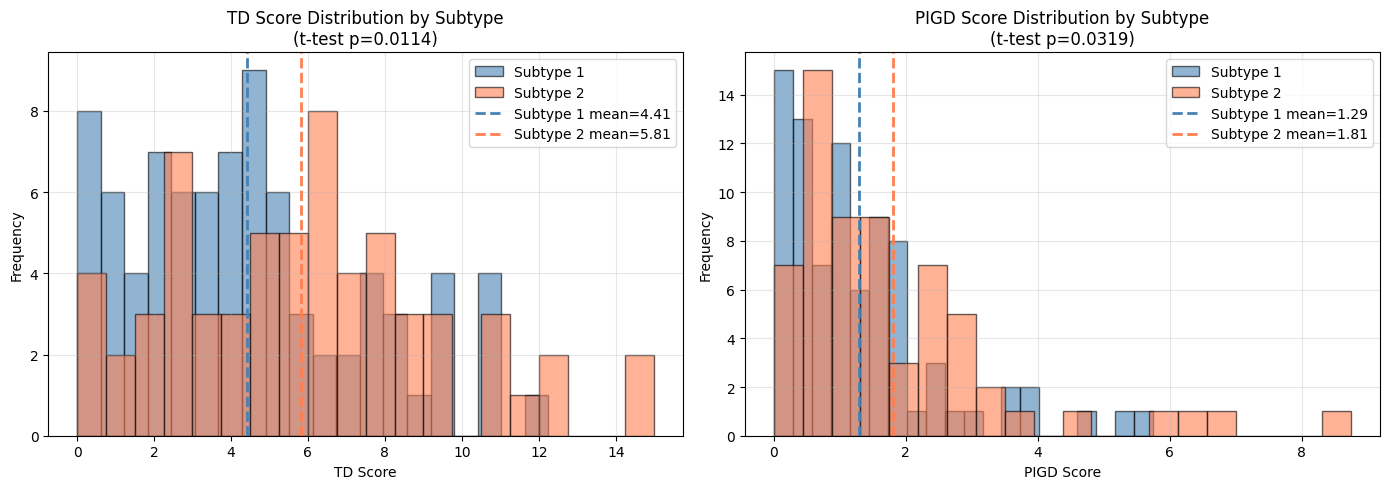

/tmp/ipykernel_23645/385389263.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([td_subtype1, td_subtype2], labels=['Subtype 1', 'Subtype 2'])
/tmp/ipykernel_23645/385389263.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([pigd_subtype1, pigd_subtype2], labels=['Subtype 1', 'Subtype 2'])


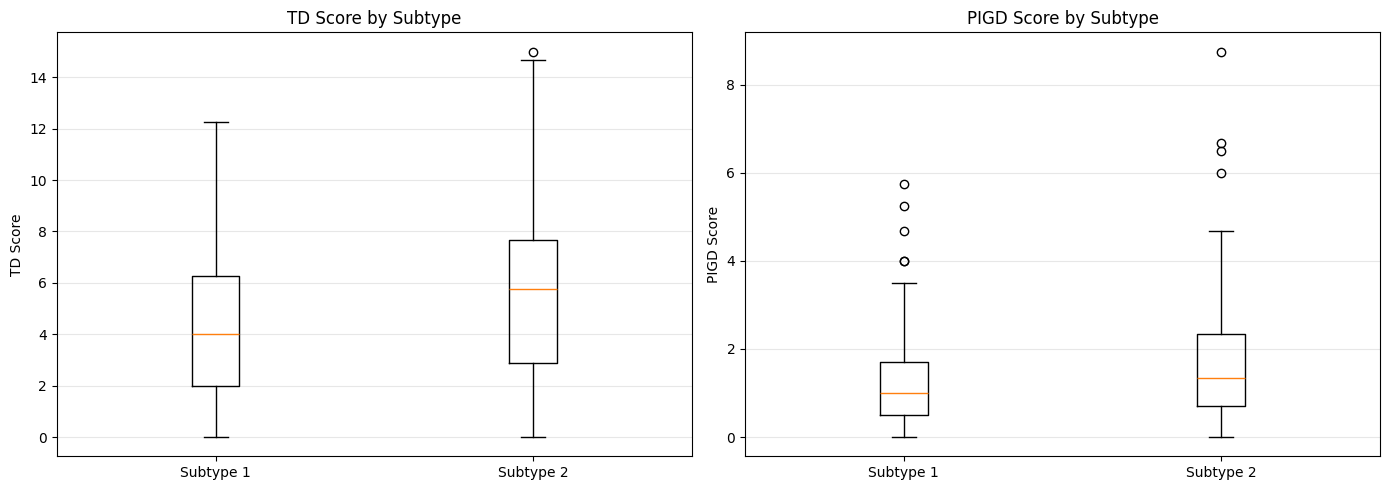

/tmp/ipykernel_23645/385389263.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([moca_subtype1, moca_subtype2], labels=['Subtype 1', 'Subtype 2'])


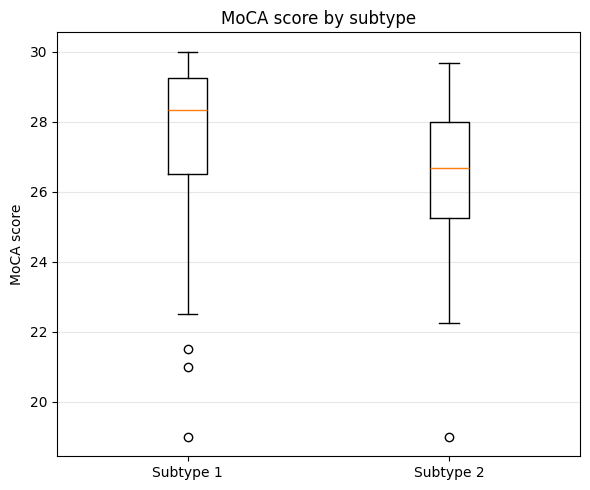

In [19]:
# Validation: Compare actual TD and PIGD scores between subtypes
# Get patient-level TD and PIGD scores (average across visits per patient)
unique_pids = np.unique(ids_valid)
pid_to_td = {}
pid_to_pigd = {}
pid_to_moca = {}

for pid in unique_pids:
    mask = (ids_all == pid)
    if mask.sum() > 0:
        # Get average scores across all visits for this patient
        pid_to_td[pid] = np.nanmean(cog_all[mask, 1])  # TD_score is column 1
        pid_to_pigd[pid] = np.nanmean(cog_all[mask, 2])  # PIGD_score is column 2
        pid_to_moca[pid] = np.nanmean(cog_all[mask, 0])  # MCATOT is column 0

# Map to subtype assignments
td_by_subtype = {1: [], 2: []}
pigd_by_subtype = {1: [], 2: []}
moca_by_subtype = {1: [], 2: []}

for pid in unique_pids:
    assignment = pid_to_assignment.get(pid, -1)
    if assignment >= 0:
        subtype_num = assignment + 1  # Convert 0->1, 1->2
        if pid in pid_to_td:
            td_by_subtype[subtype_num].append(pid_to_td[pid])
            pigd_by_subtype[subtype_num].append(pid_to_pigd[pid])
            moca_by_subtype[subtype_num].append(pid_to_moca[pid])

# Convert to arrays for statistical testing
td_subtype1 = np.array(td_by_subtype[1])
td_subtype2 = np.array(td_by_subtype[2])
pigd_subtype1 = np.array(pigd_by_subtype[1])
pigd_subtype2 = np.array(pigd_by_subtype[2])
moca_subtype1 = np.array(moca_by_subtype[1])
moca_subtype2 = np.array(moca_by_subtype[2])

# Print summary statistics
print("=== TD Score Comparison ===")
print(f"Subtype 1: mean={np.mean(td_subtype1):.3f}, median={np.median(td_subtype1):.3f}, std={np.std(td_subtype1):.3f}")
print(f"Subtype 2: mean={np.mean(td_subtype2):.3f}, median={np.median(td_subtype2):.3f}, std={np.std(td_subtype2):.3f}")

print("\n=== PIGD Score Comparison ===")
print(f"Subtype 1: mean={np.mean(pigd_subtype1):.3f}, median={np.median(pigd_subtype1):.3f}, std={np.std(pigd_subtype1):.3f}")
print(f"Subtype 2: mean={np.mean(pigd_subtype2):.3f}, median={np.median(pigd_subtype2):.3f}, std={np.std(pigd_subtype2):.3f}")

# Statistical tests
from scipy.stats import ttest_ind, mannwhitneyu

# TD score: Subtype 1 should have higher TD (more tremor-dominant)
td_stat, td_pval = ttest_ind(td_subtype1, td_subtype2)
td_u_stat, td_u_pval = mannwhitneyu(td_subtype1, td_subtype2, alternative='two-sided')

print(f"\n=== TD Score Statistical Tests ===")
print(f"t-test: t={td_stat:.3f}, p={td_pval:.4f}")
print(f"Mann-Whitney U: U={td_u_stat:.1f}, p={td_u_pval:.4f}")
print(f"Expected: Subtype 1 should have higher TD scores (more tremor-dominant)")

# PIGD score: Subtype 2 should have higher PIGD (more postural/gait issues)
pigd_stat, pigd_pval = ttest_ind(pigd_subtype1, pigd_subtype2)
pigd_u_stat, pigd_u_pval = mannwhitneyu(pigd_subtype1, pigd_subtype2, alternative='two-sided')

print(f"\n=== PIGD Score Statistical Tests ===")
print(f"t-test: t={pigd_stat:.3f}, p={pigd_pval:.4f}")
print(f"Mann-Whitney U: U={pigd_u_stat:.1f}, p={pigd_u_pval:.4f}")
print(f"Expected: Subtype 2 should have higher PIGD scores (more postural/gait issues)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TD scores
axes[0].hist(td_subtype1, bins=20, alpha=0.6, label='Subtype 1', color='steelblue', edgecolor='black')
axes[0].hist(td_subtype2, bins=20, alpha=0.6, label='Subtype 2', color='coral', edgecolor='black')
axes[0].axvline(np.mean(td_subtype1), color='steelblue', linestyle='--', linewidth=2, label=f'Subtype 1 mean={np.mean(td_subtype1):.2f}')
axes[0].axvline(np.mean(td_subtype2), color='coral', linestyle='--', linewidth=2, label=f'Subtype 2 mean={np.mean(td_subtype2):.2f}')
axes[0].set_xlabel('TD Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'TD Score Distribution by Subtype\n(t-test p={td_pval:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PIGD scores
axes[1].hist(pigd_subtype1, bins=20, alpha=0.6, label='Subtype 1', color='steelblue', edgecolor='black')
axes[1].hist(pigd_subtype2, bins=20, alpha=0.6, label='Subtype 2', color='coral', edgecolor='black')
axes[1].axvline(np.mean(pigd_subtype1), color='steelblue', linestyle='--', linewidth=2, label=f'Subtype 1 mean={np.mean(pigd_subtype1):.2f}')
axes[1].axvline(np.mean(pigd_subtype2), color='coral', linestyle='--', linewidth=2, label=f'Subtype 2 mean={np.mean(pigd_subtype2):.2f}')
axes[1].set_xlabel('PIGD Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'PIGD Score Distribution by Subtype\n(t-test p={pigd_pval:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for better comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([td_subtype1, td_subtype2], labels=['Subtype 1', 'Subtype 2'])
axes[0].set_ylabel('TD Score')
axes[0].set_title('TD Score by Subtype')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].boxplot([pigd_subtype1, pigd_subtype2], labels=['Subtype 1', 'Subtype 2'])
axes[1].set_ylabel('PIGD Score')
axes[1].set_title('PIGD Score by Subtype')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# MoCA box plot by subtype
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([moca_subtype1, moca_subtype2], labels=['Subtype 1', 'Subtype 2'])
ax.set_ylabel('MoCA score')
ax.set_title('MoCA score by subtype')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

=== TD Score Comparison ===
Subtype 1: mean=4.406, median=4.000, std=3.074
Subtype 2: mean=5.808, median=5.750, std=3.475

=== PIGD Score Comparison ===
Subtype 1: mean=1.288, median=1.000, std=1.194
Subtype 2: mean=1.810, median=1.333, std=1.693

=== TD Score Statistical Tests ===
t-test: t=-2.563, p=0.0114
Mann-Whitney U: U=1981.5, p=0.0124
Expected: Subtype 1 should have higher TD scores (more tremor-dominant)

=== PIGD Score Statistical Tests ===
t-test: t=-2.166, p=0.0319
Mann-Whitney U: U=2095.5, p=0.0400
Expected: Subtype 2 should have higher PIGD scores (more postural/gait issues)


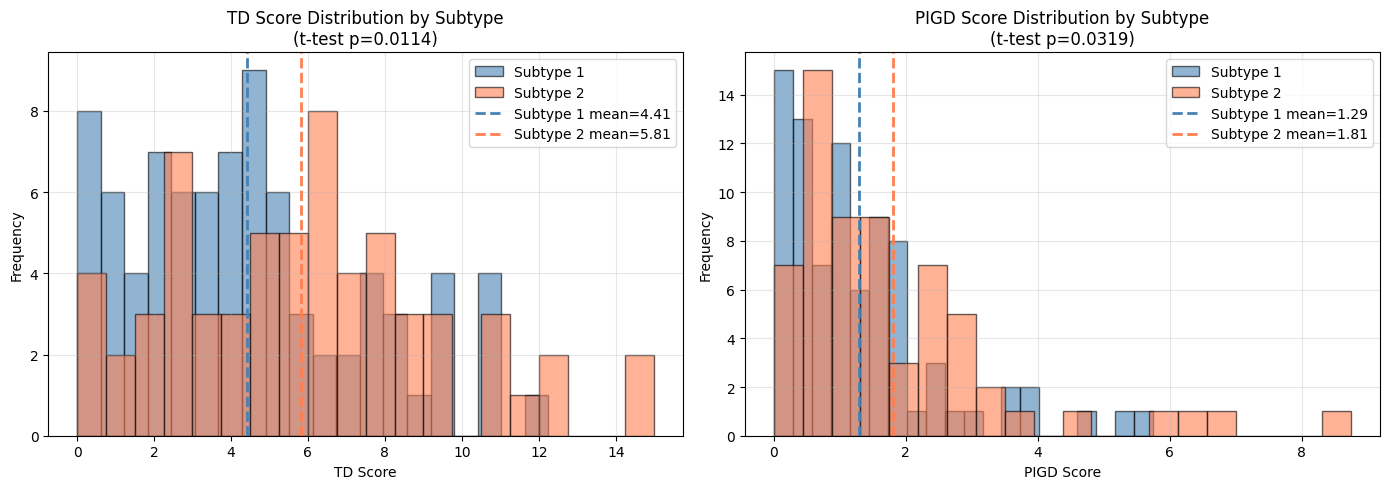

/tmp/ipykernel_23645/3179356395.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([td_subtype1, td_subtype2], labels=['Subtype 1', 'Subtype 2'])
/tmp/ipykernel_23645/3179356395.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([pigd_subtype1, pigd_subtype2], labels=['Subtype 1', 'Subtype 2'])


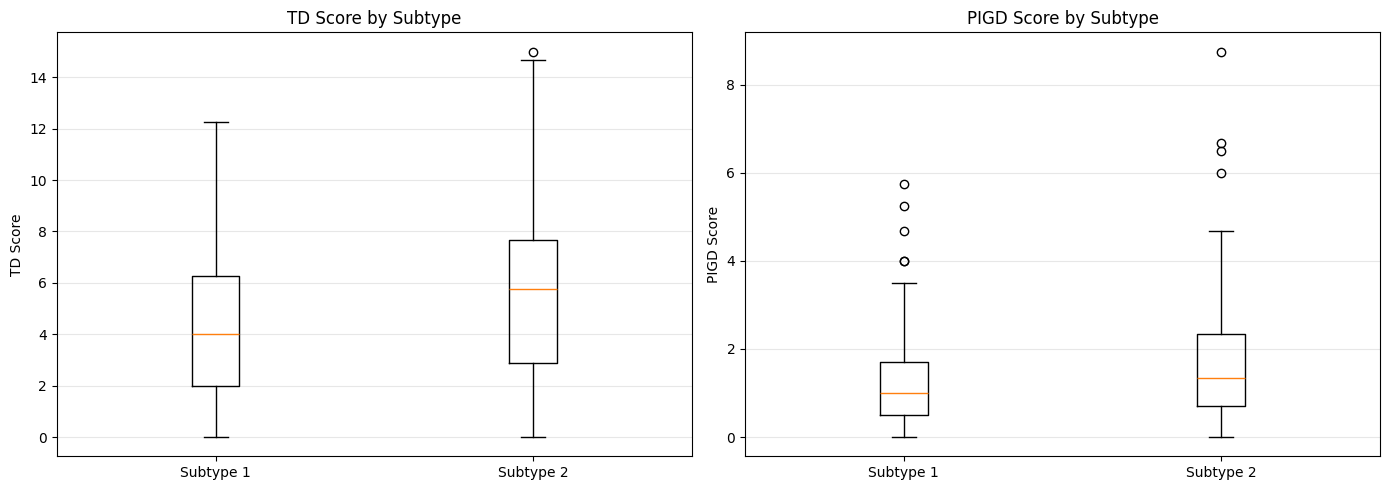

In [20]:
# Validation: Compare actual TD and PIGD scores between subtypes
# Get patient-level TD and PIGD scores (average across visits per patient)
unique_pids = np.unique(ids_valid)
pid_to_td = {}
pid_to_pigd = {}
pid_to_moca = {}

for pid in unique_pids:
    mask = (ids_all == pid)
    if mask.sum() > 0:
        # Get average scores across all visits for this patient
        pid_to_td[pid] = np.nanmean(cog_all[mask, 1])  # TD_score is column 1
        pid_to_pigd[pid] = np.nanmean(cog_all[mask, 2])  # PIGD_score is column 2
        pid_to_moca[pid] = np.nanmean(cog_all[mask, 0])  # MCATOT is column 0

# Map to subtype assignments
td_by_subtype = {1: [], 2: []}
pigd_by_subtype = {1: [], 2: []}
moca_by_subtype = {1: [], 2: []}

for pid in unique_pids:
    assignment = pid_to_assignment.get(pid, -1)
    if assignment >= 0:
        subtype_num = assignment + 1  # Convert 0->1, 1->2
        if pid in pid_to_td:
            td_by_subtype[subtype_num].append(pid_to_td[pid])
            pigd_by_subtype[subtype_num].append(pid_to_pigd[pid])
            moca_by_subtype[subtype_num].append(pid_to_moca[pid])

# Convert to arrays for statistical testing
td_subtype1 = np.array(td_by_subtype[1])
td_subtype2 = np.array(td_by_subtype[2])
pigd_subtype1 = np.array(pigd_by_subtype[1])
pigd_subtype2 = np.array(pigd_by_subtype[2])
moca_subtype1 = np.array(moca_by_subtype[1])
moca_subtype2 = np.array(moca_by_subtype[2])

# Print summary statistics
print("=== TD Score Comparison ===")
print(f"Subtype 1: mean={np.mean(td_subtype1):.3f}, median={np.median(td_subtype1):.3f}, std={np.std(td_subtype1):.3f}")
print(f"Subtype 2: mean={np.mean(td_subtype2):.3f}, median={np.median(td_subtype2):.3f}, std={np.std(td_subtype2):.3f}")

print("\n=== PIGD Score Comparison ===")
print(f"Subtype 1: mean={np.mean(pigd_subtype1):.3f}, median={np.median(pigd_subtype1):.3f}, std={np.std(pigd_subtype1):.3f}")
print(f"Subtype 2: mean={np.mean(pigd_subtype2):.3f}, median={np.median(pigd_subtype2):.3f}, std={np.std(pigd_subtype2):.3f}")

# Statistical tests
from scipy.stats import ttest_ind, mannwhitneyu

# TD score: Subtype 1 should have higher TD (more tremor-dominant)
td_stat, td_pval = ttest_ind(td_subtype1, td_subtype2)
td_u_stat, td_u_pval = mannwhitneyu(td_subtype1, td_subtype2, alternative='two-sided')

print(f"\n=== TD Score Statistical Tests ===")
print(f"t-test: t={td_stat:.3f}, p={td_pval:.4f}")
print(f"Mann-Whitney U: U={td_u_stat:.1f}, p={td_u_pval:.4f}")
print(f"Expected: Subtype 1 should have higher TD scores (more tremor-dominant)")

# PIGD score: Subtype 2 should have higher PIGD (more postural/gait issues)
pigd_stat, pigd_pval = ttest_ind(pigd_subtype1, pigd_subtype2)
pigd_u_stat, pigd_u_pval = mannwhitneyu(pigd_subtype1, pigd_subtype2, alternative='two-sided')

print(f"\n=== PIGD Score Statistical Tests ===")
print(f"t-test: t={pigd_stat:.3f}, p={pigd_pval:.4f}")
print(f"Mann-Whitney U: U={pigd_u_stat:.1f}, p={pigd_u_pval:.4f}")
print(f"Expected: Subtype 2 should have higher PIGD scores (more postural/gait issues)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TD scores
axes[0].hist(td_subtype1, bins=20, alpha=0.6, label='Subtype 1', color='steelblue', edgecolor='black')
axes[0].hist(td_subtype2, bins=20, alpha=0.6, label='Subtype 2', color='coral', edgecolor='black')
axes[0].axvline(np.mean(td_subtype1), color='steelblue', linestyle='--', linewidth=2, label=f'Subtype 1 mean={np.mean(td_subtype1):.2f}')
axes[0].axvline(np.mean(td_subtype2), color='coral', linestyle='--', linewidth=2, label=f'Subtype 2 mean={np.mean(td_subtype2):.2f}')
axes[0].set_xlabel('TD Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'TD Score Distribution by Subtype\n(t-test p={td_pval:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PIGD scores
axes[1].hist(pigd_subtype1, bins=20, alpha=0.6, label='Subtype 1', color='steelblue', edgecolor='black')
axes[1].hist(pigd_subtype2, bins=20, alpha=0.6, label='Subtype 2', color='coral', edgecolor='black')
axes[1].axvline(np.mean(pigd_subtype1), color='steelblue', linestyle='--', linewidth=2, label=f'Subtype 1 mean={np.mean(pigd_subtype1):.2f}')
axes[1].axvline(np.mean(pigd_subtype2), color='coral', linestyle='--', linewidth=2, label=f'Subtype 2 mean={np.mean(pigd_subtype2):.2f}')
axes[1].set_xlabel('PIGD Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'PIGD Score Distribution by Subtype\n(t-test p={pigd_pval:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for better comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([td_subtype1, td_subtype2], labels=['Subtype 1', 'Subtype 2'])
axes[0].set_ylabel('TD Score')
axes[0].set_title(f'TD Score by Subtype')#\n(t-test p={td_pval:.4f})')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].boxplot([pigd_subtype1, pigd_subtype2], labels=['Subtype 1', 'Subtype 2'])
axes[1].set_ylabel('PIGD Score')
axes[1].set_title(f'PIGD Score by Subtype')# \n(t-test p={pigd_pval:.4f})')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()